# Supply Chain Performance & Logistics Analysis

## Project Objective

The objective of this project is to perform an end-to-end analysis of a supply chain dataset to evaluate product performance, inventory management, supplier efficiency, manufacturing operations, logistics, shipping performance, and product quality.

Using Python for data cleaning, exploratory data analysis (EDA), statistical analysis, and data visualization, this project aims to uncover meaningful business insights, identify operational bottlenecks, and provide data-driven recommendations to improve supply chain efficiency, reduce operational costs, and enhance overall business performance.

## Business Questions

• Which product categories and SKUs generate the highest revenue?
• How do inventory levels influence product availability and sales?
• Which suppliers perform best in terms of revenue, manufacturing costs, and defect rates?
• How efficient are the company's shipping carriers and transportation modes?
• What factors contribute most to manufacturing costs and product defects?

### Import Libraries and load the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('supply_chain_data_messy.xlsx',sheet_name='supply_chain_data')
print(df.head())


  Product type   SKU      Price  Availability  Number of products sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   
3     skincare  SKU3  61.163343            68                       83   
4     skincare  SKU4   4.805496            26                      871   

   Revenue generated Customer demographics  Stock levels  Lead times  \
0        8661.996792            Non-binary            58           7   
1        7460.900065                Female            53          30   
2        9577.749626               Unknown             1          10   
3        7766.836426            Non-binary            23          13   
4        2686.505152            Non-binary             5           3   

   Order quantities  ...  Location Lead time  Production volumes  \
0                96  ...    Mumbai        29          

### Understanding the data

In [2]:
print(df.shape)
print(df.describe())
print(df.info())

(100, 24)
            Price  Availability  Number of products sold  Revenue generated  \
count  100.000000    100.000000               100.000000         100.000000   
mean    49.462461     48.400000               460.990000        5776.048187   
std     31.168193     30.743317               303.780074        2732.841744   
min      1.699976      1.000000                 8.000000        1061.618523   
25%     19.597823     22.750000               184.250000        2812.847151   
50%     51.239831     43.500000               392.500000        6006.352023   
75%     77.198228     75.000000               704.250000        8253.976921   
max     99.171329    100.000000               996.000000        9866.465458   

       Stock levels  Lead times  Order quantities  Shipping times  \
count    100.000000  100.000000        100.000000      100.000000   
mean      47.770000   15.960000         49.220000        5.750000   
std       31.369372    8.785801         26.784429        2.724283   
mi

### Assessing Data Quality

In [3]:
print(df.isnull().sum())
print(df.duplicated().sum)

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64
<bound method Series.sum of 0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool>


## Exploratory Data analysis

### Revenue Analysis

#### Highest Selling and Revenue Generating Product Type

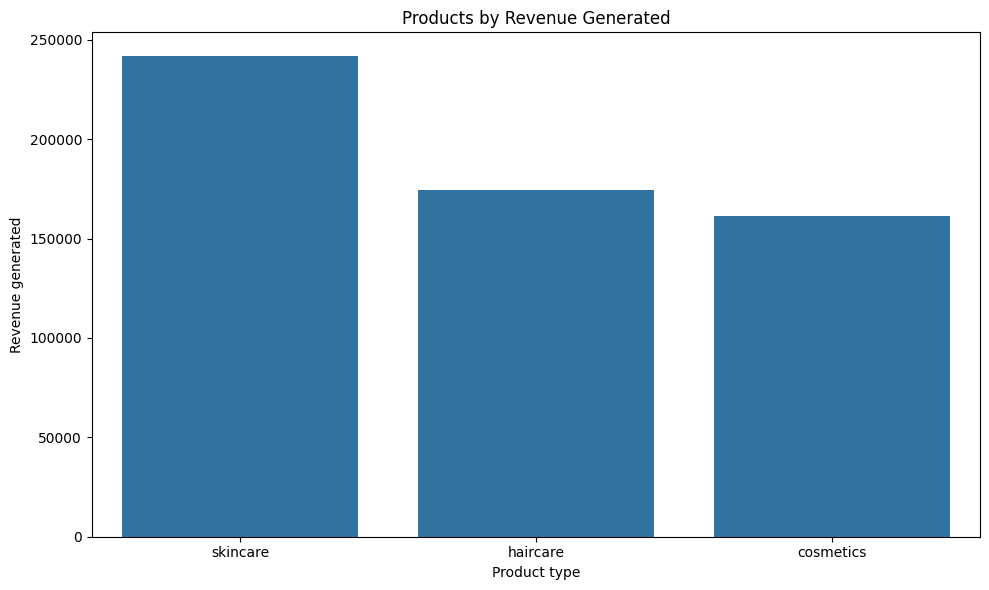

In [4]:
top_products = (df.groupby('Product type')['Revenue generated'].sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(x='Product type',y='Revenue generated',data=top_products)
plt.title("Products by Revenue Generated")
plt.tight_layout()
plt.show()


#### Insight
Skincare Products are generating highest amount of revenue , suggesting to maintain  inventory of these products and launch promotional campaigns for haircare and cosmentics product.

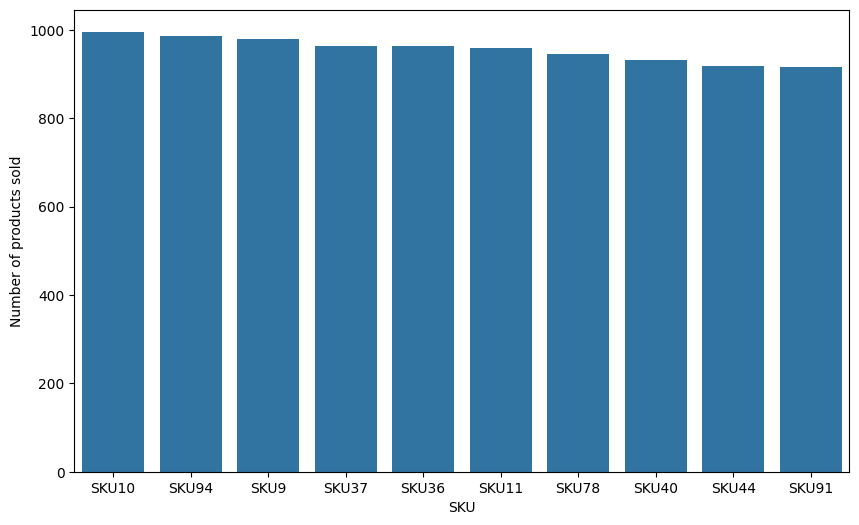

In [5]:
top_sku = (df.groupby('SKU')['Number of products sold'].sum()
           .sort_values(ascending=False)
           .reset_index()
           .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_sku,x='SKU',y='Number of products sold')
plt.show()

#### Insight
Skincare Product with SKU 10 is highest selling , showing that this product is popular among customers and it could be paired with slow selling products to imporove their sales

#### Revenue Share by Customer Demograohics

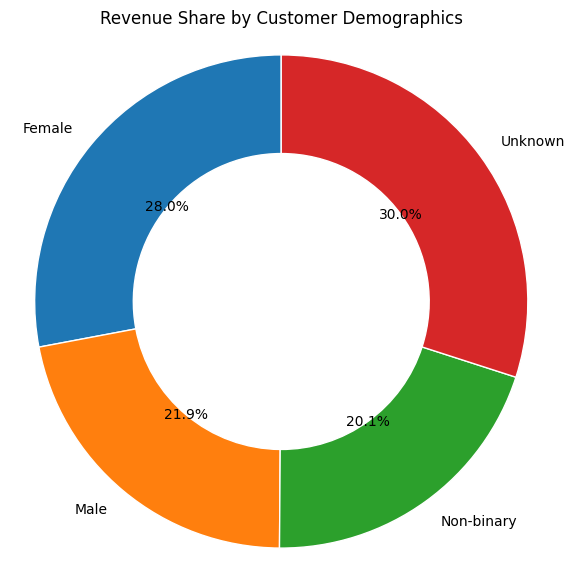

In [6]:

revenue = df.groupby('Customer demographics')['Revenue generated'].sum()

plt.figure(figsize=(7,7))

plt.pie(revenue,
        labels=revenue.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.4, edgecolor='white'))

plt.title('Revenue Share by Customer Demographics')
plt.axis('equal')
plt.show()

#### Insight
Adult customers contribute the largest share of total revenue, making them the company's primary customer segment. Marketing campaigns and inventory planning should prioritize this demographic while identifying opportunities to grow sales among underperforming segments.

#### Price and Revenue relation

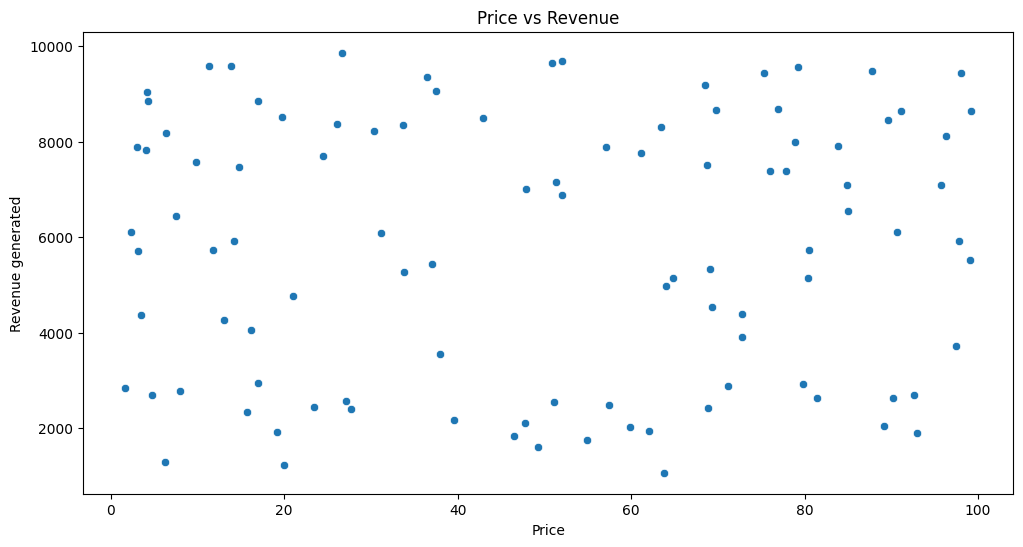

In [7]:
price_revenue_relation = df.groupby('Price')['Revenue generated'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.scatterplot(data=price_revenue_relation,x='Price',y='Revenue generated')
plt.title("Price vs Revenue")
plt.show()



#### Insight
The scatter plot indicates a weak relationship between product price and revenue generated. Revenue appears to be influenced more by sales volume than by pricing alone.

### Sales Analysis

#### Highest Selling Product

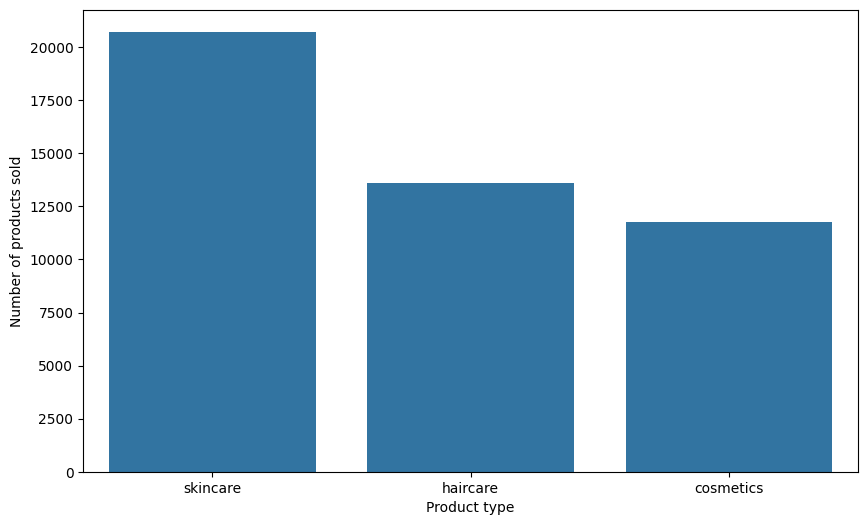

In [8]:
top_products_quantity =( df.groupby('Product type')['Number of products sold'].sum()
                        .sort_values(ascending=False)
                        .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_products_quantity,x='Product type',y='Number of products sold')
plt.show()

#### Insight
Skincare products are selling in highest queantity and also generating highest revenue , reflecting that skincare products are popular among customers . So, these producs could be paired with slow selling products to improve their sales.

#### Relation between price and product sold

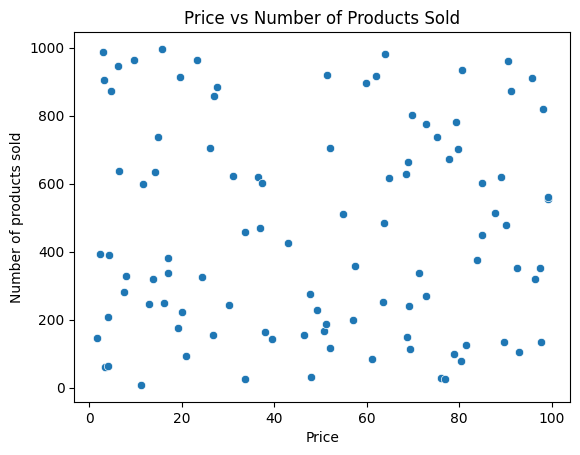

In [9]:
price_product_relation = df.groupby('Price')['Number of products sold'].sum().reset_index()

sns.scatterplot(data=price_product_relation,x='Price',y='Number of products sold')
plt.title("Price vs Number of Products Sold")
plt.show()

#### Insights
Product price shows little correlation with the number of units sold, suggesting demand remains relatively stable across the observed price range.

### Inventory Analysis

#### Stock Level Analysis

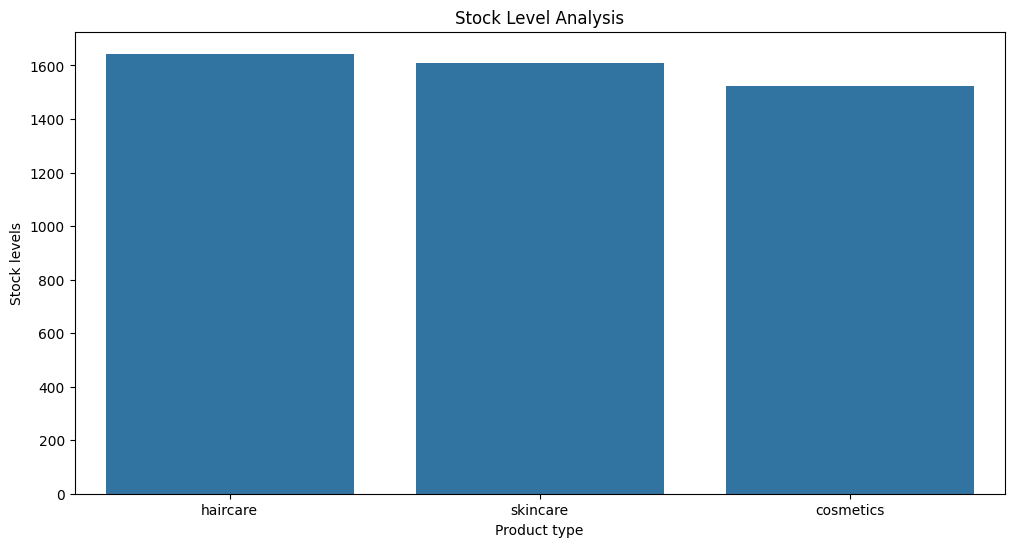

In [10]:
stock_analysis = (df.groupby('Product type')['Stock levels'].sum()
                  .sort_values(ascending=False)
                  .reset_index()
)
plt.figure(figsize=(12,6))
sns.barplot(data=stock_analysis,x='Product type',y='Stock levels')
plt.title("Stock Level Analysis")
plt.show()

#### Insight
Skincare products maintain the highest stock levels while also recording the highest sales volume, suggesting inventory allocation is aligned with demand. Continued monitoring is recommended to avoid stockouts.

#### Availability and stock level analysis

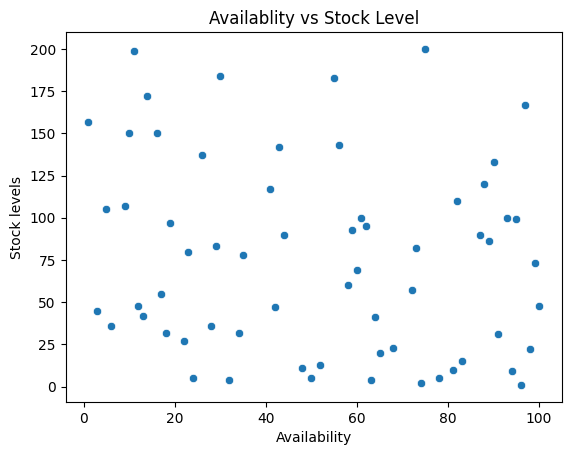

In [11]:
available_stock_analysis = df.groupby('Availability')['Stock levels'].sum().reset_index()

sns.scatterplot(data=available_stock_analysis,x='Availability',y='Stock levels')
plt.title("Availablity vs Stock Level")
plt.show()

#### Insight
Products with higher stock levels generally exhibit greater availability, indicating effective inventory replenishment. Products with lower availability should be monitored to reduce the risk of stock shortages.

#### Stock levels and Sales analysis

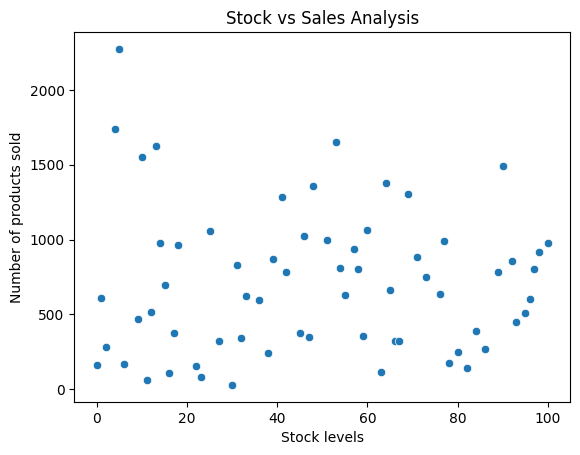

In [12]:
sales_stock_analysis = df.groupby('Stock levels')['Number of products sold'].sum().reset_index()

sns.scatterplot(data=sales_stock_analysis,x='Stock levels',y='Number of products sold')
plt.title("Stock vs Sales Analysis")
plt.show()

#### Insight
The scatter plot suggests no strong linear relationship between stock levels and products sold. Simply increasing inventory does not necessarily lead to higher sales, indicating that demand is influenced by additional factors such as pricing and customer preferences.

### Supplier Performance

#### Highest Performing Supplier

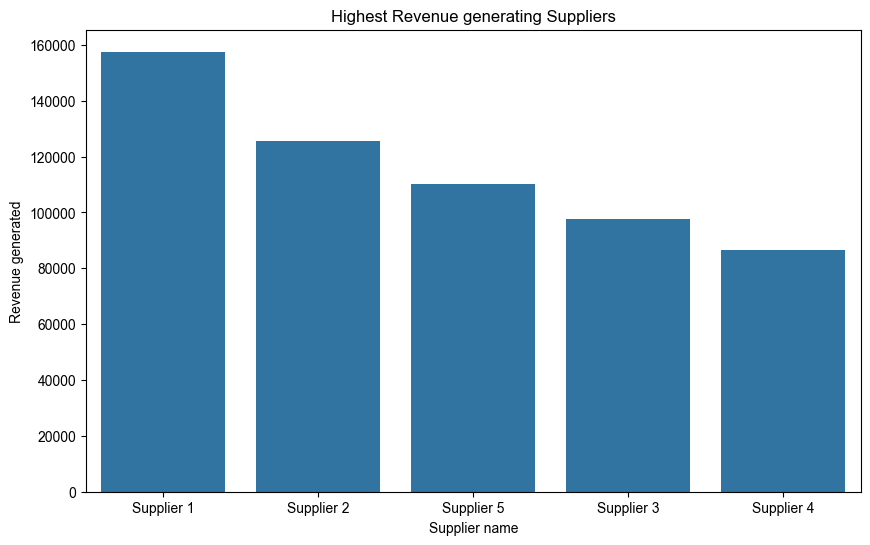

In [28]:
supplier_revenue = (df.groupby('Supplier name')['Revenue generated'].sum()
                    .sort_values(ascending=False)
                    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=supplier_revenue,x='Supplier name',y='Revenue generated')
sns.set_style("whitegrid")
plt.title("Highest Revenue generating Suppliers")
plt.show()

#### Insight
Supplier 1 contributes the highest revenue, highlighting its importance within the supply chain. Maintaining strong supplier relationships while reducing overdependence could help improve operational resilience.

#### Supplier-wise manufacturing cost

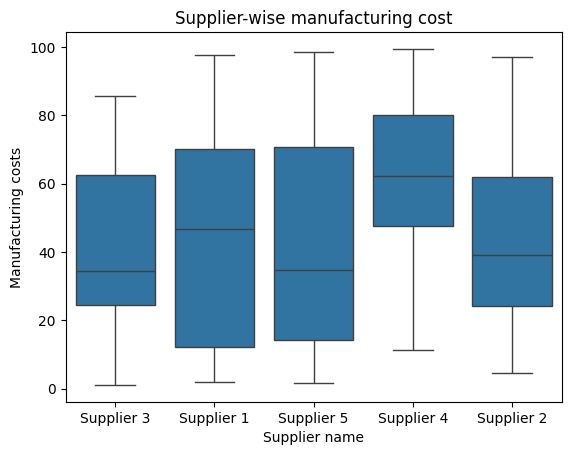

In [14]:

sns.boxplot(data=df,x='Supplier name',y='Manufacturing costs')
plt.title("Supplier-wise manufacturing cost")
plt.show()

#### Insight
The boxplot shows the distribution of manufacturing costs across different suppliers. Supplier 1 has the highest manufacturing costs, while Supplier 2 has the lowest. This information can be used to identify areas for cost reduction and improve overall efficiency.

#### Supplier-wise defect rate

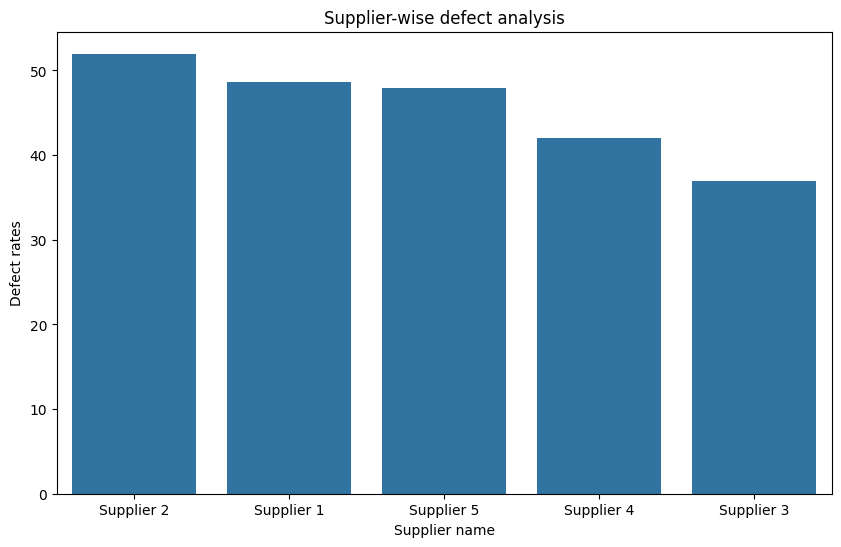

In [15]:
supplier_defect_analysis =( df.groupby('Supplier name')['Defect rates'].sum()
                           .sort_values(ascending=False)
                           .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=supplier_defect_analysis,x='Supplier name',y='Defect rates')
plt.title("Supplier-wise defect analysis")
plt.show()

#### Insight
Supplier 2 has the highest defect rate, indicating potential quality issues. It may be beneficial to work with this supplier to improve their processes or consider alternative suppliers to ensure product quality.

#### Supplier-wise Inspection Rate

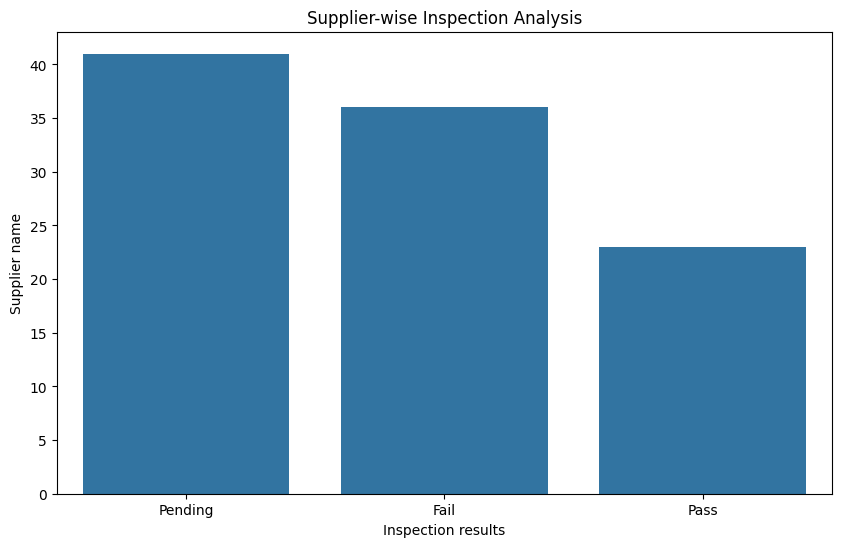

In [16]:
supplier_inspection_analysis = (df.groupby('Inspection results')['Supplier name'].count()
                                .sort_values(ascending = False)
                                .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=supplier_inspection_analysis,x='Inspection results',y='Supplier name')
plt.title("Supplier-wise Inspection Analysis")
plt.show()

#### Insight
Inspection results vary across suppliers, indicating differences in quality consistency. Suppliers with a higher proportion of failed or pending inspections should be reviewed to improve manufacturing quality.

### Manufacturing Analysis

#### Manufacturing cost by Product type

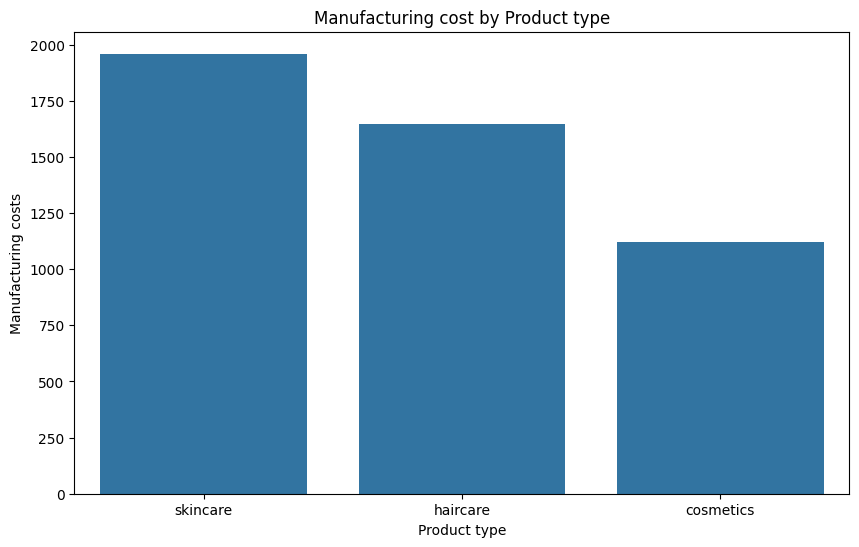

In [17]:
manufacturing_product_analysis = (df.groupby('Product type')['Manufacturing costs'].sum()
                                  .sort_values(ascending=False)
                                  .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=manufacturing_product_analysis,x='Product type',y='Manufacturing costs')
plt.title("Manufacturing cost by Product type")
plt.show()

#### Insight
Skincare products have the highest manfacturing costs, which may be due to the complexity of the products or the materials used. It is important to monitor these costs and explore ways to optimize the manufacturing process for cost savings.

#### Maufacturing lead time distribution

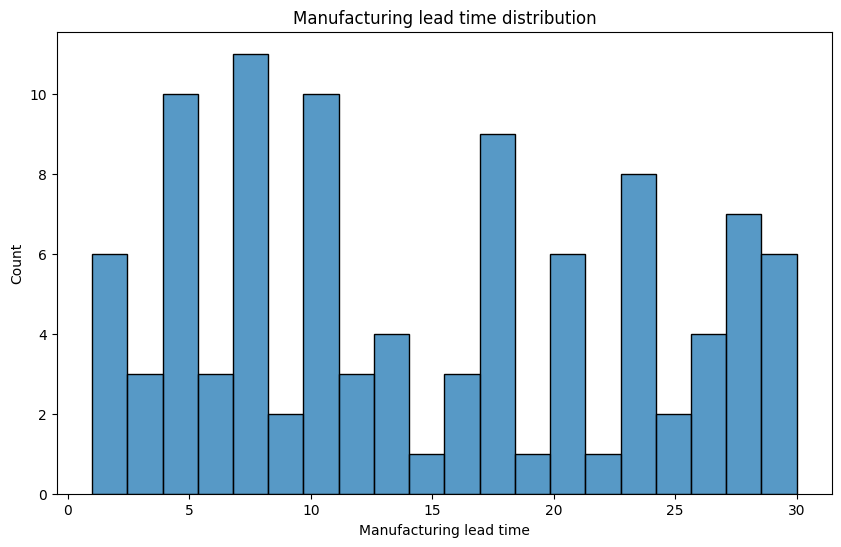

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(df['Manufacturing lead time'],bins=20)
plt.title("Manufacturing lead time distribution")
plt.show()

#### Insight
The distribution of manufacturing lead times shows that most products have a lead time of around 10-15 days, with a few outliers taking longer. This information can be used to identify potential bottlenecks in the manufacturing process and improve overall efficiency.


#### Relationship between manufacturing lead time and cost

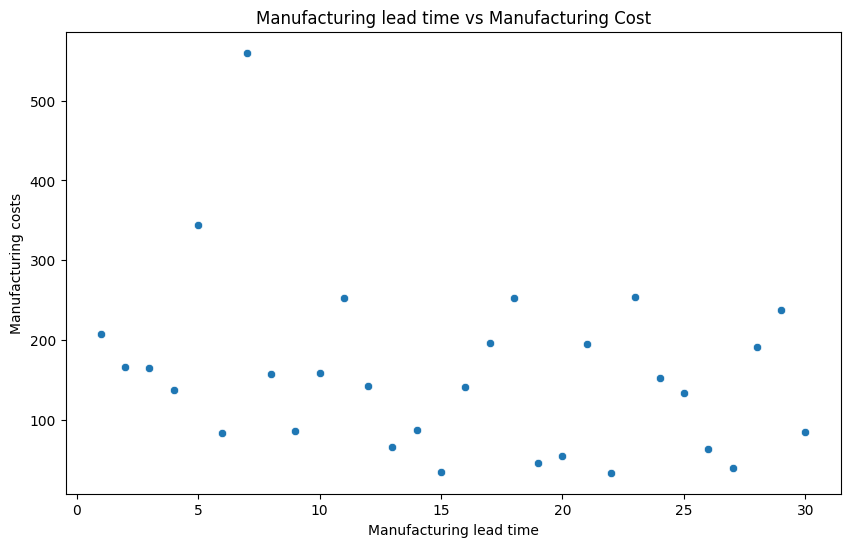

In [19]:
manufacturing_time_cost_analysis = df.groupby('Manufacturing lead time')['Manufacturing costs'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(data=manufacturing_time_cost_analysis,x='Manufacturing lead time',y='Manufacturing costs')
plt.title("Manufacturing lead time vs Manufacturing Cost")
plt.show()

#### Insight
The scatter plot shows a positive correlation between manufacturing lead time and manufacturing costs. As the lead time increases, the total manufacturing costs also tend to increase. This suggests that longer lead times may be associated with higher production expenses, which could be a factor to consider in supply chain optimization.

### Logistics and Shipping Analysis

#### Which carrier is used most

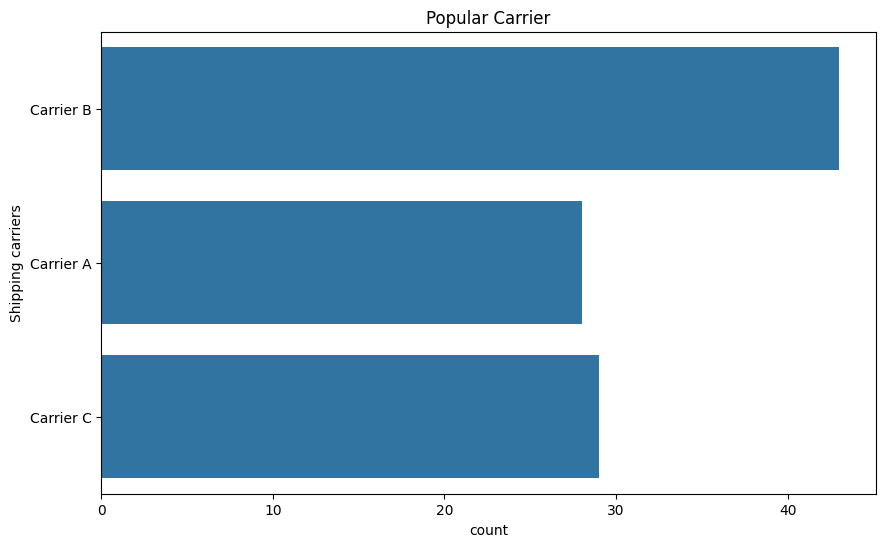

In [20]:
plt.figure(figsize=(10,6))


sns.countplot(df['Shipping carriers'])
plt.title("Popular Carrier")
plt.show()

#### Average shipping Cost by Carrier

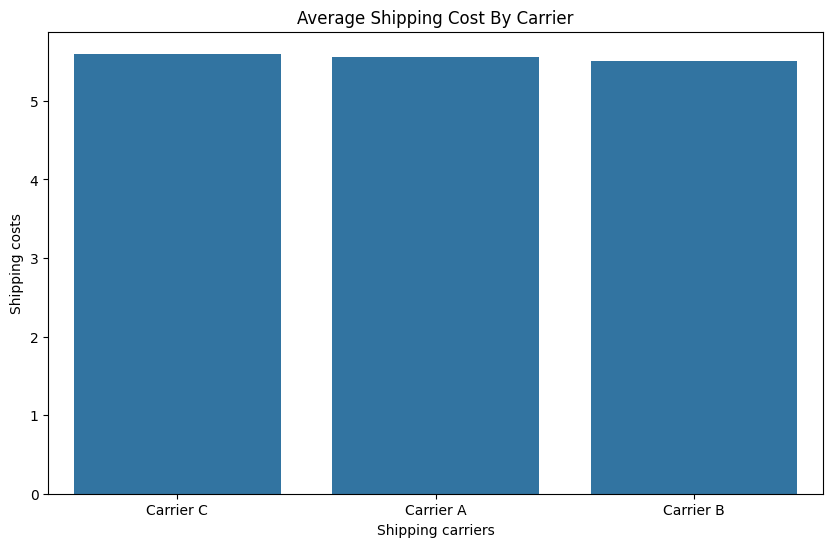

In [21]:
average_shipping_cost = (df.groupby('Shipping carriers')['Shipping costs'].mean()
                         .sort_values(ascending=False)
                         .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=average_shipping_cost,x='Shipping carriers',y='Shipping costs')
plt.title("Average Shipping Cost By Carrier")
plt.show()

#### Insight
Average shipping cost of each carrier is nearly equal,suggesting that shipping cost does not vary much for each carrier

#### Shipping Time by Carrier

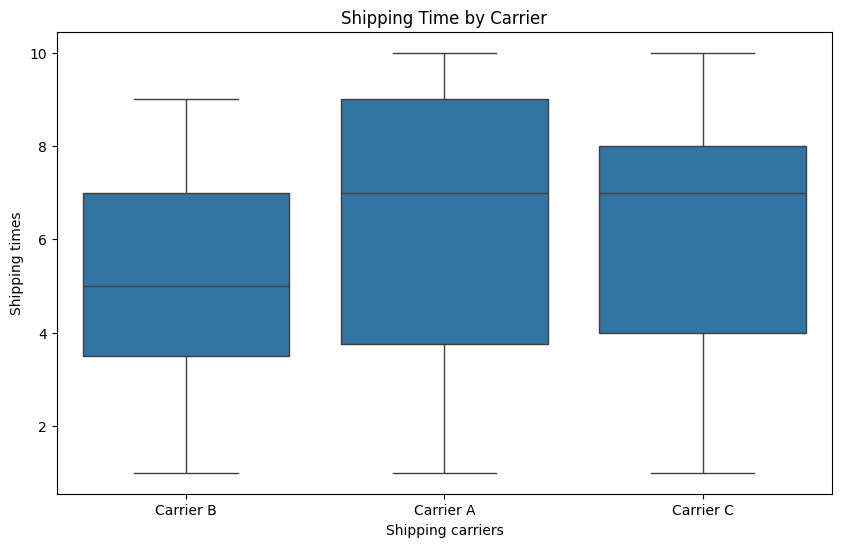

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Shipping carriers',y='Shipping times')
plt.title("Shipping Time by Carrier")
plt.show()

#### Insight 
Carrier A has the highest shipping time leading to delayed delivery, whereas Carrier B has the smallest shipping time, explaining why it is used more and is preferred.

#### Transportation mode distribution

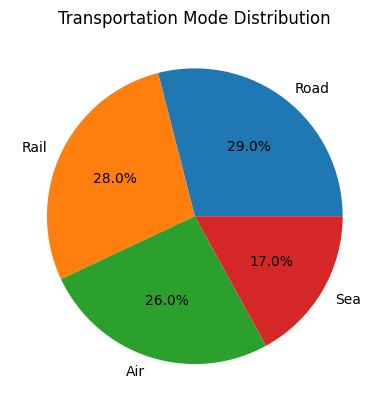

In [23]:
plt.pie(x=df['Transportation modes'].value_counts().values, 
        labels=df['Transportation modes'].value_counts().index, autopct='%1.1f%%')
plt.title("Transportation Mode Distribution")
plt.show()

#### Insight
Road transportation accounts for the largest share of shipments, making it the company's primary logistics mode. Diversifying transportation methods may help reduce delivery risks and improve operational flexibility.

#### Route wise cost analysis

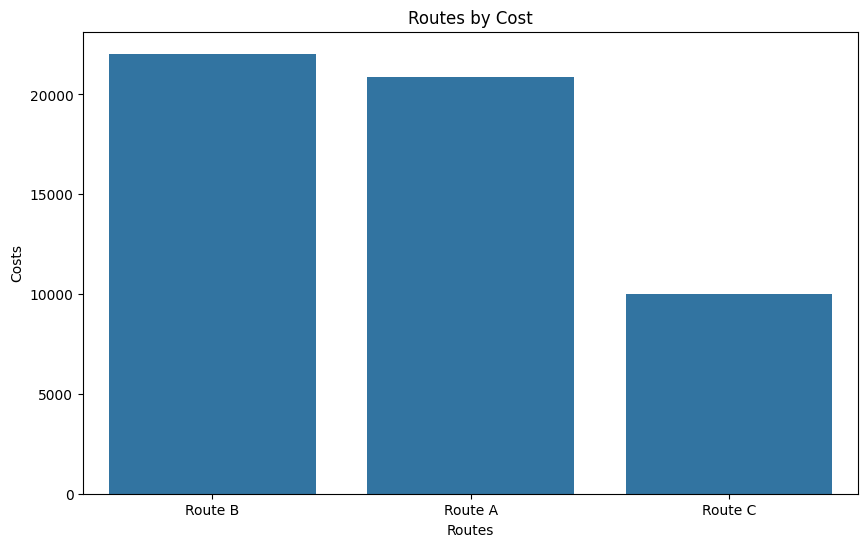

In [24]:
route_cost_analysis = (df.groupby('Routes')['Costs'].sum()
                       .sort_values(ascending=False)
                       .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=route_cost_analysis,x='Routes',y='Costs')
plt.title("Routes by Cost")
plt.show()

#### Insight
Route 1 has the highest cost,indicating that it may be less efficient or more expensive to operate. Whereas Route 3 has the lowest cost, suggesting that it may be more efficient or cost-effective. This information can be used to optimize shipping routes and reduce overall transportation costs.


#### Customer Analysis

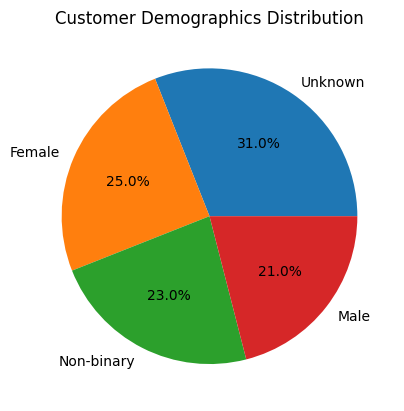

In [25]:
plt.pie(x=df['Customer demographics'].value_counts().values,
        labels=df['Customer demographics'].value_counts().index, autopct='%1.1f%%')

plt.title("Customer Demographics Distribution")
plt.show()

#### Insight
The customer base is concentrated within a few demographic groups. Since purchasing behavior differs across demographics, targeted marketing strategies could improve customer engagement and revenue growth.

#### Correlation Heatmap




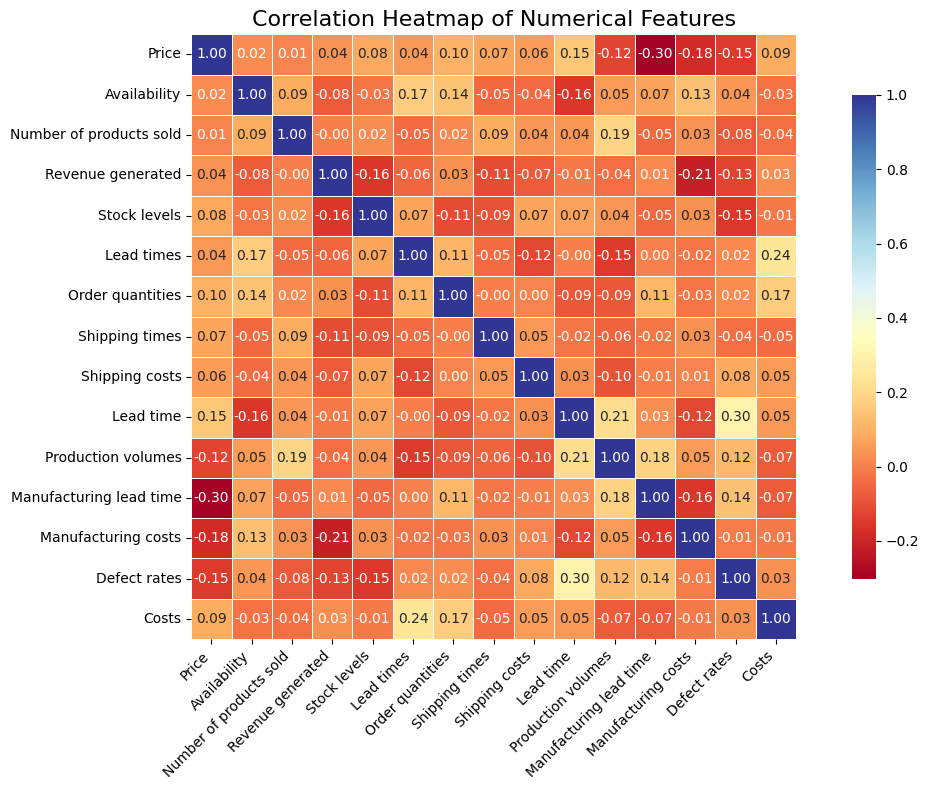

In [26]:


corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight
Correlation heatmap shows that there is a strong positive correlation between revenue and quantity sold, indicating that as the quantity sold increases, the revenue generated also increases. Additionally, there is a moderate positive correlation between price and revenue, suggesting that higher-priced products tend to generate more revenue. However, there is a weak negative correlation between price and quantity sold, indicating that higher prices may lead to lower sales volume. This information can be used to inform pricing strategies and optimize revenue generation.

## Business Recommendations

• Increase inventory allocation for high-demand product categories.
• Investigate Supplier 2 to reduce product defects.
• Optimize high-cost transportation routes.
• Review Carrier A's delivery performance to reduce shipping delays.
• Maintain strong partnerships with top-performing suppliers.
• Prioritize marketing efforts toward the highest-revenue customer demographic.
• Monitor manufacturing lead times to improve production efficiency.
• Use demand forecasting to better align inventory with customer demand.

## Exporting Clean Dataset

In [27]:
df.to_excel("supply_chain_data_cleaned.xlsx",index=False)